# Food classification in soup, salad and sandwich using Keras

Yanis Graber, Benjamin Meyer
Feburary 2026
Milestone I


The aim of this project is the creation of a machine learning algorithm capable of classifying foods according to the categories soup, salad and sandwich. This algorithm should be able to take images as input and categorise them according to these categories. 
For this, a number of goals needed to be achieved:
1) Aquisition of an appropriate dataset, preferrably of large size.  
2) Labeling of dataset  
3) Creation and training of algorithm
4) Designing a system of measuring the algorithms accuracy  

We chose this project due to the popular theory that any food can be classified as soup, salad or sandwich and as we were curious how such an image classification algorithm worked. Furthermore, the skills from this project could be easily applied to other machine learning applications.
The main challenges of this project are targets 3 and 4, as there exist well labelled, refined datasets of food images. Thus, the focus of this project is familiarization with keras and general machine learning workflows.  
This project uses keras, numpy and tensorflow for the algorithm and jupyter notebook as an IDE. As common with machine learning applications, it is built in Python. The most important sources are kaggle for datasets and the keras/tensorflow documentations.  
As this is a common ML exercise, there are a few similar projects such as https://github.com/rileykwok/Food-Classification.  
However, our project does not aim to reccognize specific food but rather classify them according to our defined categories. This proves challanging, as even classifying foods by hand this way can be challenging. For example, pasta and green salad are both classified as salads but look very dissimilar. However, many pasta dishes may look similar to pizza which is a sandwich.  

We sourced our data from https://www.kaggle.com/datasets/kmader/food41. The dataset contains food seperated into 101 categories with a total of 1000 images each. These categories were classified into the 3 categories and put together to form 3 large folders of foods. Examples of classifications are:
Sandwich: Pizza & Gyoza  (Food wrapped in other food, ofter carbs)  
Salad: Fried rice & Lasagna  (Mixed foods covered in a sauce)  
Soup: Sweet and sour soup & Chocolatte mousse  (Largely liquid foods potentially including food swimming in the liquid phase)  
To refine data, the images were analyzed by hand and mislabled food removed. ALso removed were images where a topping or decoration obstructed the dish.
There are few things to note about the dataset. Most images are taken from a similar angle, namely from approximately 45° as if sitting at a table. Threrefore, images outside of the dataset should be taken in the same manner. As the dataset is of food, there is a large difference between foods of the same categorie. This is aggrevated by the vastly different lighting, exposure, contrast etc. of each image.

*visualisierung der daten*
*feature skalierung*

In [1]:
import os
import numpy as np
import keras
from keras import layers
from tensorflow import data as tf_data
import matplotlib.pyplot as plt


Here the training and test data sets are created using keras. 80% of images are used for training and 20% for testing, also the image resolution and batch sizes are defined here.  
Fraction is used to speed up testing by limiting the amount of images used. 1 = All images are used; 0 = No images are used

In [2]:
image_size = (180, 180)
batch_size = 128

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    "Training_Data",
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)
class_names = train_ds.class_names

# --- Use only a fraction of the training data ---
fraction = 0.20  # Use 5% of training batches
num_train_batches = int(len(train_ds) * fraction)
train_ds = train_ds.take(num_train_batches)


Found 72869 files belonging to 3 classes.
Using 58296 files for training.
Using 14573 files for validation.


We can use matplotlib to show a random assortment of training data together with their respective label.

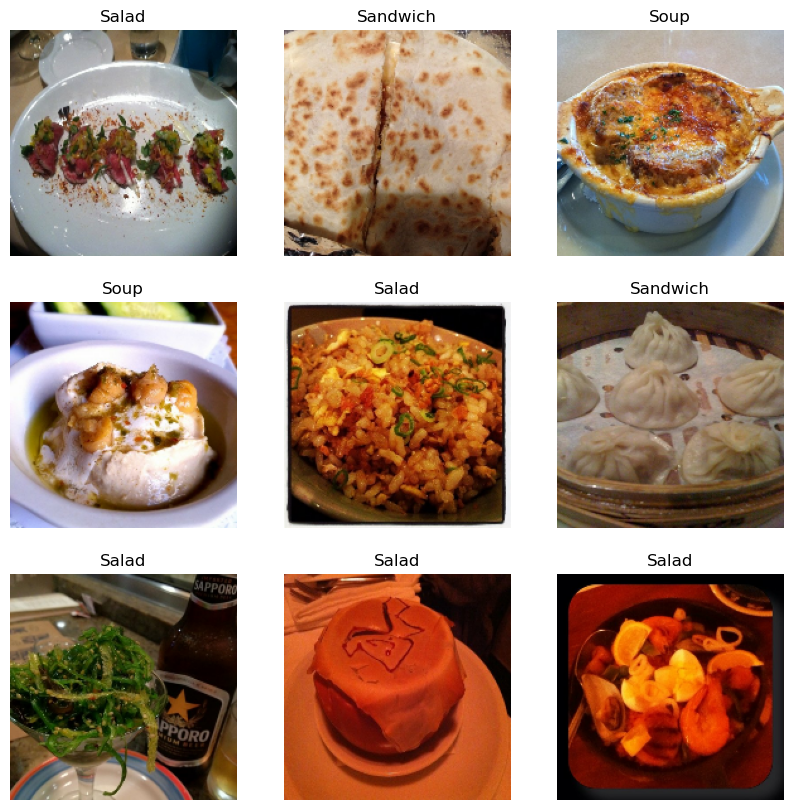

In [3]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")


As an additional preprocessing step we can randomly flip images and slightly rotate them to give the model even more diverse data and further prevent overfitting. Afterwards we can plot some of those variations for one image. 

In [4]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

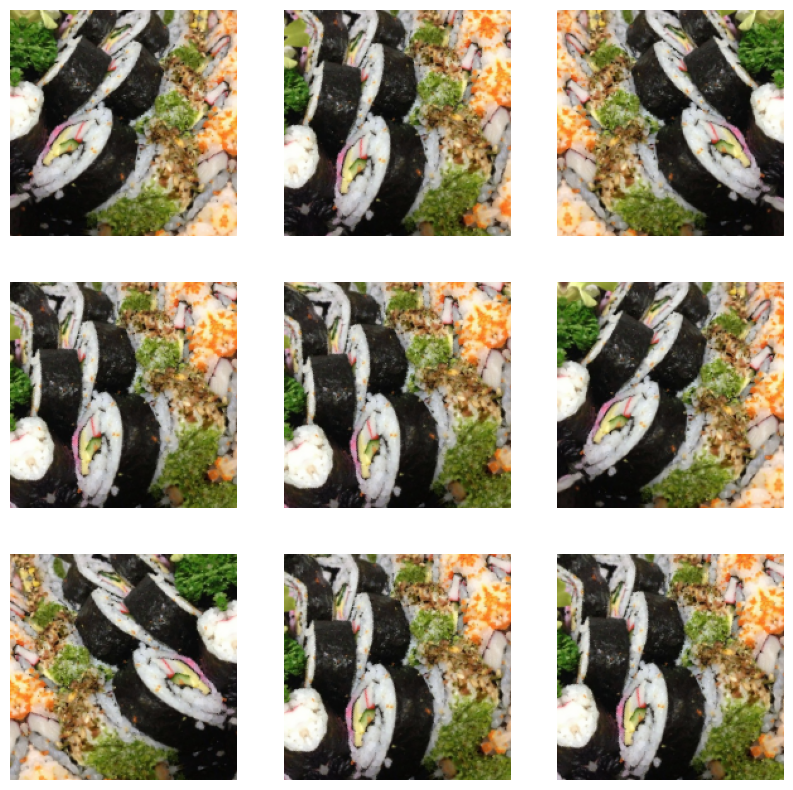

In [5]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented_images[0]).astype("uint8"))
        plt.axis("off")


In [6]:
# Apply `data_augmentation` to the training images.
train_ds = train_ds.map(
    lambda img, label: (data_augmentation(img), label),
    num_parallel_calls=tf_data.AUTOTUNE,
)
# Prefetching samples in GPU memory helps maximize GPU utilization.
train_ds = train_ds.prefetch(tf_data.AUTOTUNE)
val_ds = val_ds.prefetch(tf_data.AUTOTUNE)


In [7]:
def make_model(input_shape, num_classes):
    base_model = keras.applications.EfficientNetV2S(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )
    base_model.trainable = False  # Freeze pretrained weights initially

    inputs = keras.Input(shape=input_shape)
    x = keras.applications.efficientnet_v2.preprocess_input(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.25)(x)
    outputs = layers.Dense(num_classes)(x)
    return keras.Model(inputs, outputs)


model = make_model(input_shape=image_size + (3,), num_classes=3)
#keras.utils.plot_model(model, show_shapes=True)


In [ ]:
epochs = 50
callbacks = [
    keras.callbacks.ModelCheckpoint("save_at_{epoch}.keras"),
    keras.callbacks.EarlyStopping(
        monitor="val_acc",
        patience=5,        # Stop if no improvement for 5 epochs
        restore_best_weights=True
    ),
]
model.compile(
    optimizer=keras.optimizers.Adam(3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=[keras.metrics.CategoricalAccuracy(name="acc")],
)
history = model.fit(
    train_ds,
    epochs=epochs,
    callbacks=callbacks,
    validation_data=val_ds,
)

Epoch 1/50
42/91 ━━━━━━━━━━━━━━━━━━━━ 1:10 1s/step - acc: 0.1491 - loss: 5.3450

In [ ]:
from matplotlib import pyplot as plt

plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
model = keras.saving.load_model("save_at_10.keras")


In [ ]:
img = keras.utils.load_img("Training_Data/Sandwich/12863.jpg", target_size=image_size)
plt.imshow(img)

img_array = keras.utils.img_to_array(img)
img_array = keras.ops.expand_dims(img_array, 0)  # Create batch axis

preds = model.predict(img_array)
index = np.argmax(preds[0])
print(class_names[index], preds[0])
